# Análisis y selección de experimentos

Este notebook analiza los resultados auditados de K-Means y Archetypal Analysis.

La selección de configuraciones se realiza exclusivamente con las métricas del conjunto de validación. El conjunto de prueba permanece reservado hasta congelar el protocolo de evaluación.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Ruta principal del proyecto
def encontrar_raiz_proyecto():
    """Busca la raíz del proyecto desde el directorio actual."""

    ruta_actual = Path.cwd().resolve()

    for ruta_candidata in (
        ruta_actual,
        *ruta_actual.parents,
    ):
        tiene_src = (
            ruta_candidata
            / "src"
        ).is_dir()

        tiene_notebooks = (
            ruta_candidata
            / "notebooks"
        ).is_dir()

        if tiene_src and tiene_notebooks:
            return ruta_candidata

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto."
    )


RUTA_PROYECTO = encontrar_raiz_proyecto()

print(
    "Raíz del proyecto:",
    RUTA_PROYECTO,
)

# Archivo consolidado de experimentos
RUTA_REGISTRO = RUTA_PROYECTO / "resultados" / "registro_experimentos.csv"


# Comprobar que el archivo exista antes de cargarlo
if not RUTA_REGISTRO.exists():
    raise FileNotFoundError(
        f"No se encontró el registro de experimentos en:\n{RUTA_REGISTRO}"
    )


# Cargar el registro completo
df_experimentos = pd.read_csv(RUTA_REGISTRO)

print(f"Dimensiones del registro: {df_experimentos.shape}")
print("\nEjecuciones por modelo:")
display(df_experimentos["modelo"].value_counts().rename("n_ejecuciones"))

display(df_experimentos.head())

Raíz del proyecto: C:\Users\adanm\Code\tesis
Dimensiones del registro: (1094, 43)

Ejecuciones por modelo:


modelo
kmeans                 1080
archetypal_analysis      14
Name: n_ejecuciones, dtype: int64

,experiment_id,fecha,modelo,dataset,discretizacion,n_puntos,normalizacion,inicializacion,K,seed_modelo,...,davies_bouldin_val,silhouette_val,ami_val,optimizador,nnls_max_iter_optimizer,nnls_const,version_scipy,version_archetypes,convergio,loss_final
0,3163938d2fc24f9f,2026-09-04T15:51:25+00:00,kmeans,interpolacion_50,interpolacion,50,minmax,random,2,0,...,1.345484,0.341947,0.574907,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6d5f290a6df42744,2026-09-04T15:51:27+00:00,kmeans,interpolacion_50,interpolacion,50,minmax,k-means++,2,0,...,1.346409,0.341698,0.572279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,40744154b486a7f4,2026-09-04T15:51:28+00:00,kmeans,interpolacion_50,interpolacion,50,minmax,random,2,1,...,1.346409,0.341698,0.572279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0f11203d2256e72b,2026-09-04T15:51:29+00:00,kmeans,interpolacion_50,interpolacion,50,minmax,k-means++,2,1,...,1.345451,0.341947,0.575039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,b8cdbba7fa9bb384,2026-09-04T15:51:30+00:00,kmeans,interpolacion_50,interpolacion,50,minmax,random,2,2,...,1.345484,0.341947,0.574907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Seleccionar únicamente los experimentos de K-Means
df_kmeans = (
    df_experimentos
    .loc[df_experimentos["modelo"] == "kmeans"]
    .copy()
)


# Columnas que identifican una ejecución única de K-Means
columnas_configuracion = [
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
    "seed_modelo",
]


# Resumen de la grilla experimental
resumen_grilla = pd.Series(
    {
        "datasets": df_kmeans["dataset"].nunique(),
        "normalizaciones": df_kmeans["normalizacion"].nunique(),
        "inicializaciones": df_kmeans["inicializacion"].nunique(),
        "valores_de_K": df_kmeans["K"].nunique(),
        "semillas": df_kmeans["seed_modelo"].nunique(),
        "ejecuciones": len(df_kmeans),
        "configuraciones_duplicadas": df_kmeans.duplicated(
            subset=columnas_configuracion
        ).sum(),
    },
    name="resultado",
)

display(resumen_grilla)

print("\nEstados de ejecución:")
display(df_kmeans["estado"].value_counts(dropna=False))

datasets                         4
normalizaciones                  3
inicializaciones                 2
valores_de_K                     9
semillas                         5
ejecuciones                   1080
configuraciones_duplicadas       0
Name: resultado, dtype: int64


Estados de ejecución:


estado
OK    1080
Name: count, dtype: int64

In [4]:
# Variables que definen una familia de K-Means
columnas_familia = [
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
]


# Resumir las cinco semillas de cada familia
df_familias_kmeans = (
    df_kmeans
    .groupby(columnas_familia, as_index=False)
    .agg(
        n_semillas=("seed_modelo", "nunique"),

        mse_val_media=("mse_val", "mean"),
        mse_val_std=("mse_val", "std"),

        rss_val_media=("rss_val", "mean"),
        rss_val_std=("rss_val", "std"),

        purity_val_media=("purity_val", "mean"),
        purity_val_std=("purity_val", "std"),

        davies_bouldin_val_media=("davies_bouldin_val", "mean"),
        davies_bouldin_val_std=("davies_bouldin_val", "std"),

        silhouette_val_media=("silhouette_val", "mean"),
        silhouette_val_std=("silhouette_val", "std"),

        ami_val_media=("ami_val", "mean"),
        ami_val_std=("ami_val", "std"),
    )
)


print(f"Número de familias: {len(df_familias_kmeans)}")

print("\nCantidad de semillas por familia:")
display(
    df_familias_kmeans["n_semillas"]
    .value_counts()
    .sort_index()
    .rename("n_familias")
)

display(df_familias_kmeans.head())

Número de familias: 216

Cantidad de semillas por familia:


n_semillas
5    216
Name: n_familias, dtype: int64

,dataset,normalizacion,inicializacion,K,n_semillas,mse_val_media,mse_val_std,rss_val_media,rss_val_std,purity_val_media,purity_val_std,davies_bouldin_val_media,davies_bouldin_val_std,silhouette_val_media,silhouette_val_std,ami_val_media,ami_val_std
0,interpolacion_100,centered,k-means++,2,5,0.004486,1.430989e-08,9231.205617,0.029444,0.748425,0.000181,1.076795,0.000031,0.362806,0.000011,0.356222,0.000212
1,interpolacion_100,centered,k-means++,3,5,0.003737,5.794472e-08,7688.667104,0.119227,0.863530,0.000447,1.402099,0.000218,0.261550,0.000065,0.387007,0.000549
2,interpolacion_100,centered,k-means++,4,5,0.003476,7.330551e-08,7152.529146,0.150833,0.896715,0.000414,1.734681,0.000330,0.192407,0.000049,0.361073,0.000572
3,interpolacion_100,centered,k-means++,5,5,0.003355,9.110242e-06,6903.969590,18.745234,0.897696,0.014726,2.092164,0.059318,0.151630,0.020848,0.340913,0.006816
4,interpolacion_100,centered,k-means++,6,5,0.003235,6.301917e-06,6655.818517,12.966825,0.905074,0.004017,2.138925,0.027739,0.134297,0.011471,0.341632,0.008243


In [5]:
# Componentes de la familia que permanecen fijos al comparar valores de K
columnas_base = [
    "dataset",
    "normalizacion",
    "inicializacion",
]


# Métricas y sentido de optimización
criterios_metricas = {
    "mse_val_media": "min",
    "purity_val_media": "max",
    "davies_bouldin_val_media": "min",
    "silhouette_val_media": "max",
    "ami_val_media": "max",
}


# Guardar el mejor K según cada métrica
mejores_k = []

for metrica, sentido in criterios_metricas.items():

    if sentido == "min":
        indices = (
            df_familias_kmeans
            .groupby(columnas_base)[metrica]
            .idxmin()
        )
    else:
        indices = (
            df_familias_kmeans
            .groupby(columnas_base)[metrica]
            .idxmax()
        )

    resultado_metrica = (
        df_familias_kmeans
        .loc[indices, columnas_base + ["K", metrica]]
        .rename(
            columns={
                "K": f"K_mejor_{metrica}",
                metrica: f"valor_mejor_{metrica}",
            }
        )
    )

    mejores_k.append(resultado_metrica)


# Unir los resultados en una tabla
df_mejores_k_por_metrica = mejores_k[0]

for tabla in mejores_k[1:]:
    df_mejores_k_por_metrica = df_mejores_k_por_metrica.merge(
        tabla,
        on=columnas_base,
        how="inner",
    )


df_mejores_k_por_metrica = (
    df_mejores_k_por_metrica
    .sort_values(columnas_base)
    .reset_index(drop=True)
)

display(df_mejores_k_por_metrica)

,dataset,normalizacion,inicializacion,K_mejor_mse_val_media,valor_mejor_mse_val_media,K_mejor_purity_val_media,valor_mejor_purity_val_media,K_mejor_davies_bouldin_val_media,valor_mejor_davies_bouldin_val_media,K_mejor_silhouette_val_media,valor_mejor_silhouette_val_media,K_mejor_ami_val_media,valor_mejor_ami_val_media
0,interpolacion_100,centered,k-means++,10,0.002977,10,0.915883,2,1.076795,2,0.362806,3,0.387007
1,interpolacion_100,centered,random,10,0.002984,10,0.915990,2,1.076827,2,0.362794,3,0.386804
2,interpolacion_100,minmax,k-means++,10,0.010276,3,0.920723,2,1.371370,2,0.331306,2,0.576180
3,interpolacion_100,minmax,random,10,0.010285,3,0.920694,2,1.371303,2,0.331376,2,0.576411
4,interpolacion_100,zscore,k-means++,10,0.147524,5,0.919703,2,1.258849,2,0.366569,2,0.597454
5,interpolacion_100,zscore,random,10,0.147497,5,0.919664,2,1.258840,2,0.366569,2,0.597482
6,interpolacion_50,centered,k-means++,10,0.002907,10,0.913686,2,1.065944,2,0.367133,3,0.380982
7,interpolacion_50,centered,random,10,0.002914,10,0.913414,2,1.065951,2,0.367129,3,0.380917
8,interpolacion_50,minmax,k-means++,10,0.011374,3,0.917749,2,1.346043,2,0.341786,2,0.573485
9,interpolacion_50,minmax,random,10,0.011382,3,0.917749,2,1.345847,2,0.341848,2,0.573883


In [6]:
# Ordenar las familias para estudiar la evolución al aumentar K
df_evolucion_kmeans = (
    df_familias_kmeans
    .sort_values(columnas_base + ["K"])
    .reset_index(drop=True)
    .copy()
)


# Agrupación dentro de la cual los valores son comparables
grupos_base = df_evolucion_kmeans.groupby(
    columnas_base,
    sort=False,
)


# Valor de MSE obtenido con el K anterior
df_evolucion_kmeans["mse_val_media_anterior"] = (
    grupos_base["mse_val_media"]
    .shift(1)
)


# Reducción porcentual del MSE al agregar un centroide
df_evolucion_kmeans["reduccion_mse_porcentual"] = (
    (
        df_evolucion_kmeans["mse_val_media_anterior"]
        - df_evolucion_kmeans["mse_val_media"]
    )
    / df_evolucion_kmeans["mse_val_media_anterior"]
    * 100
)


# Cambios absolutos en las demás métricas respecto del K anterior
metricas_cambio = [
    "purity_val_media",
    "davies_bouldin_val_media",
    "silhouette_val_media",
    "ami_val_media",
]

for metrica in metricas_cambio:
    df_evolucion_kmeans[f"cambio_{metrica}"] = (
        grupos_base[metrica]
        .diff()
    )


# Mostrar una combinación completa como comprobación
columnas_mostrar = [
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
    "mse_val_media",
    "reduccion_mse_porcentual",
    "purity_val_media",
    "davies_bouldin_val_media",
    "silhouette_val_media",
    "ami_val_media",
]

display(
    df_evolucion_kmeans
    .loc[
        (df_evolucion_kmeans["dataset"] == "interpolacion_100")
        & (df_evolucion_kmeans["normalizacion"] == "centered")
        & (df_evolucion_kmeans["inicializacion"] == "k-means++"),
        columnas_mostrar,
    ]
)

,dataset,normalizacion,inicializacion,K,mse_val_media,reduccion_mse_porcentual,purity_val_media,davies_bouldin_val_media,silhouette_val_media,ami_val_media
0,interpolacion_100,centered,k-means++,2,0.004486,NaN,0.748425,1.076795,0.362806,0.356222
1,interpolacion_100,centered,k-means++,3,0.003737,16.710044,0.863530,1.402099,0.261550,0.387007
2,interpolacion_100,centered,k-means++,4,0.003476,6.973094,0.896715,1.734681,0.192407,0.361073
3,interpolacion_100,centered,k-means++,5,0.003355,3.475128,0.897696,2.092164,0.151630,0.340913
4,interpolacion_100,centered,k-means++,6,0.003235,3.594325,0.905074,2.138925,0.134297,0.341632
5,interpolacion_100,centered,k-means++,7,0.003130,3.234807,0.903742,2.123185,0.124328,0.333387
6,interpolacion_100,centered,k-means++,8,0.003063,2.152880,0.905434,2.221843,0.106813,0.326912
7,interpolacion_100,centered,k-means++,9,0.003018,1.456604,0.910371,2.338918,0.096572,0.319365
8,interpolacion_100,centered,k-means++,10,0.002977,1.354534,0.915883,2.431402,0.086926,0.313663


In [7]:
# Métricas que compararemos entre inicializaciones
metricas_comparacion = [
    "mse_val_media",
    "purity_val_media",
    "davies_bouldin_val_media",
    "silhouette_val_media",
    "ami_val_media",
]


# Colocar las dos inicializaciones lado a lado
df_comparacion_inicializaciones = (
    df_familias_kmeans
    .pivot(
        index=["dataset", "normalizacion", "K"],
        columns="inicializacion",
        values=metricas_comparacion,
    )
)


# Resumir las diferencias entre random y k-means++
resumen_diferencias = []

for metrica in metricas_comparacion:

    valores_kmeans_pp = df_comparacion_inicializaciones[
        (metrica, "k-means++")
    ]

    valores_random = df_comparacion_inicializaciones[
        (metrica, "random")
    ]

    diferencia_absoluta = (
        valores_kmeans_pp - valores_random
    ).abs()

    promedio_absoluto = (
        valores_kmeans_pp.abs() + valores_random.abs()
    ) / 2

    diferencia_porcentual = (
        diferencia_absoluta / promedio_absoluto * 100
    )

    resumen_diferencias.append(
        {
            "metrica": metrica,
            "diferencia_absoluta_media": diferencia_absoluta.mean(),
            "diferencia_absoluta_mediana": diferencia_absoluta.median(),
            "diferencia_absoluta_maxima": diferencia_absoluta.max(),
            "diferencia_porcentual_media": diferencia_porcentual.mean(),
            "diferencia_porcentual_maxima": diferencia_porcentual.max(),
        }
    )


df_resumen_inicializaciones = pd.DataFrame(
    resumen_diferencias
)

display(df_resumen_inicializaciones)

,metrica,diferencia_absoluta_media,diferencia_absoluta_mediana,diferencia_absoluta_maxima,diferencia_porcentual_media,diferencia_porcentual_maxima
0,mse_val_media,0.000030,0.000003,0.000521,0.181067,1.553376
1,purity_val_media,0.001409,0.000350,0.010867,0.155196,1.200950
2,davies_bouldin_val_media,0.017444,0.002952,0.156632,0.837459,6.257195
3,silhouette_val_media,0.003478,0.001433,0.024857,2.341904,12.405565
4,ami_val_media,0.001713,0.000601,0.018013,0.494194,4.934425


In [9]:
# Identificar el mayor desacuerdo entre inicializaciones
mayores_diferencias = []

for metrica in metricas_comparacion:

    valores_kmeans_pp = df_comparacion_inicializaciones[
        (metrica, "k-means++")
    ]

    valores_random = df_comparacion_inicializaciones[
        (metrica, "random")
    ]

    diferencia_absoluta = (
        valores_kmeans_pp - valores_random
    ).abs()

    promedio_absoluto = (
        valores_kmeans_pp.abs() + valores_random.abs()
    ) / 2

    diferencia_porcentual = (
        diferencia_absoluta / promedio_absoluto * 100
    )

    indice_maximo = diferencia_porcentual.idxmax()

    mayores_diferencias.append(
        {
            "metrica": metrica,
            "dataset": indice_maximo[0],
            "normalizacion": indice_maximo[1],
            "K": indice_maximo[2],
            "valor_kmeans++": valores_kmeans_pp.loc[indice_maximo],
            "valor_random": valores_random.loc[indice_maximo],
            "diferencia_absoluta": diferencia_absoluta.loc[indice_maximo],
            "diferencia_porcentual": diferencia_porcentual.loc[indice_maximo],
        }
    )


df_mayores_diferencias = pd.DataFrame(
    mayores_diferencias
)

display(df_mayores_diferencias)

,metrica,dataset,normalizacion,K,valor_kmeans++,valor_random,diferencia_absoluta,diferencia_porcentual
0,mse_val_media,interpolacion_50,centered,4,0.003420,0.003473,0.000054,1.553376
1,purity_val_media,medianas_fase_50,centered,8,0.899436,0.910303,0.010867,1.200950
2,davies_bouldin_val_media,medianas_fase_100,zscore,10,2.581545,2.424913,0.156632,6.257195
3,silhouette_val_media,interpolacion_50,zscore,8,0.070560,0.079892,0.009332,12.405565
4,ami_val_media,medianas_fase_50,centered,5,0.374048,0.356036,0.018013,4.934425


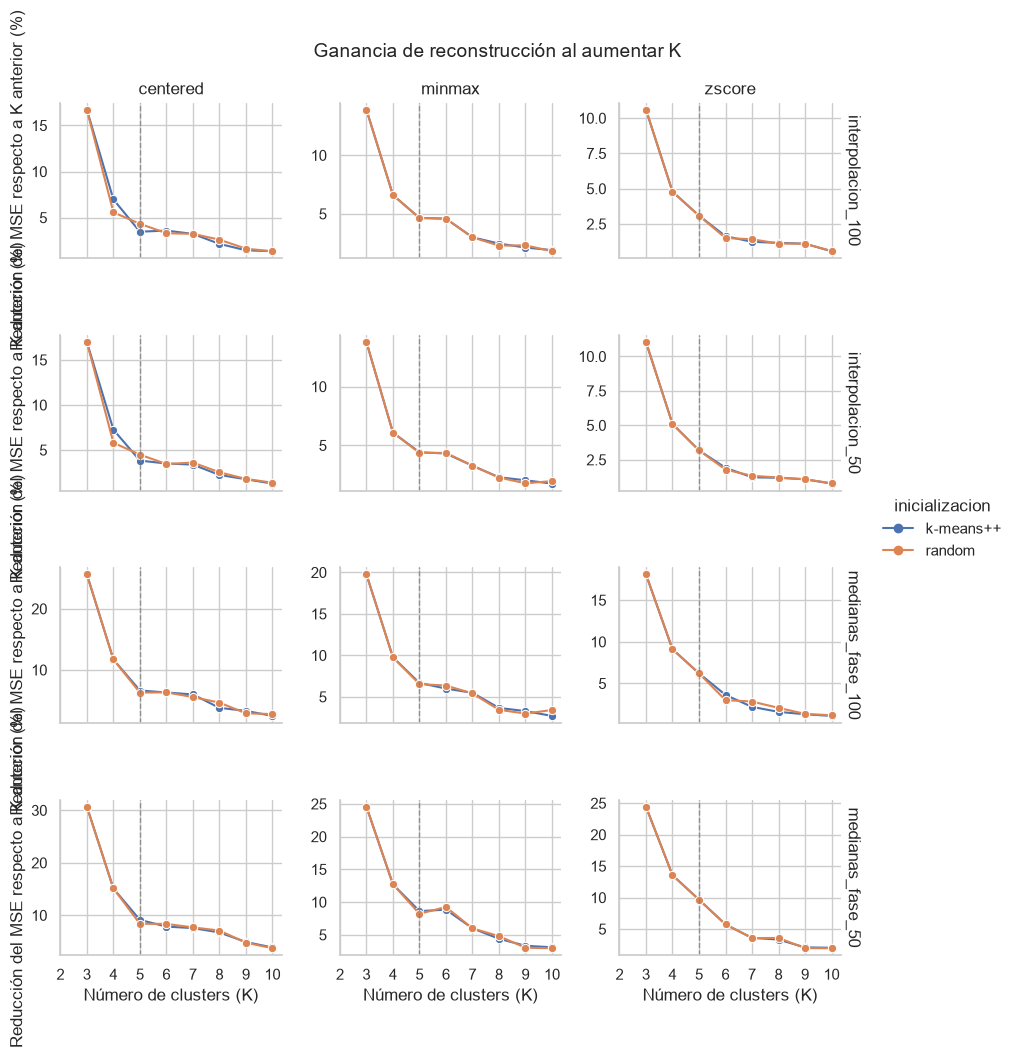

In [12]:
# Configuración visual general
sns.set_theme(style="whitegrid")


# Evolución de la reducción porcentual del MSE
grafico_codo = sns.relplot(
    data=df_evolucion_kmeans,
    x="K",
    y="reduccion_mse_porcentual",
    hue="inicializacion",
    row="dataset",
    col="normalizacion",
    kind="line",
    marker="o",
    height=2.4,
    aspect=1.25,
    facet_kws={
        "sharex": True,
        "sharey": False,
        "margin_titles": True,
    },
)


# Etiquetas
grafico_codo.set_axis_labels(
    "Número de clusters (K)",
    "Reducción del MSE respecto a K anterior (%)",
)

grafico_codo.set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
)


# Marcar K=5 y ajustar los ejes
for eje in grafico_codo.axes.flat:
    eje.axvline(
        x=5,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.8,
    )
    eje.set_xticks(range(2, 11))


grafico_codo.fig.suptitle(
    "Ganancia de reconstrucción al aumentar K",
    y=1.02,
    fontsize=14,
)

plt.show()

In [13]:
def calcular_codo_mse(grupo):
    """
    Calcula el codo como el punto de máxima distancia entre
    la curva normalizada del MSE y la recta que une sus extremos.
    """
    grupo = grupo.sort_values("K").copy()

    k_normalizado = (
        (grupo["K"] - grupo["K"].min())
        / (grupo["K"].max() - grupo["K"].min())
    )

    mse_normalizado = (
        (grupo["mse_val_media"] - grupo["mse_val_media"].min())
        / (
            grupo["mse_val_media"].max()
            - grupo["mse_val_media"].min()
        )
    )

    recta_extremos = 1 - k_normalizado
    distancia = recta_extremos - mse_normalizado

    posicion_codo = distancia.idxmax()

    return {
        "K_codo": int(grupo.loc[posicion_codo, "K"]),
        "distancia_codo": distancia.loc[posicion_codo],
    }


# Calcular el codo para las 24 combinaciones
resultados_codo = []

for valores_grupo, grupo in df_familias_kmeans.groupby(columnas_base):

    resultado = calcular_codo_mse(grupo)

    resultados_codo.append(
        {
            "dataset": valores_grupo[0],
            "normalizacion": valores_grupo[1],
            "inicializacion": valores_grupo[2],
            "K_codo": resultado["K_codo"],
            "distancia_codo": resultado["distancia_codo"],
        }
    )


df_codos_kmeans = pd.DataFrame(resultados_codo)

display(df_codos_kmeans)

print("\nFrecuencia de los valores de K detectados como codo:")
display(
    df_codos_kmeans["K_codo"]
    .value_counts()
    .sort_index()
    .rename("n_combinaciones")
)

,dataset,normalizacion,inicializacion,K_codo,distancia_codo
0,interpolacion_100,centered,k-means++,4,0.419406
1,interpolacion_100,centered,random,4,0.387937
2,interpolacion_100,minmax,k-means++,4,0.333829
3,interpolacion_100,minmax,random,4,0.334839
4,interpolacion_100,zscore,k-means++,4,0.423315
5,interpolacion_100,zscore,random,4,0.422890
6,interpolacion_50,centered,k-means++,4,0.415897
7,interpolacion_50,centered,random,4,0.383925
8,interpolacion_50,minmax,k-means++,4,0.333388
9,interpolacion_50,minmax,random,4,0.334242



Frecuencia de los valores de K detectados como codo:


K_codo
4    21
5     3
Name: n_combinaciones, dtype: int64

In [14]:
# Conservar únicamente la región candidata del codo
df_candidatas_kmeans = (
    df_familias_kmeans
    .loc[df_familias_kmeans["K"].isin([4, 5])]
    .copy()
    .reset_index(drop=True)
)


metricas_maximizar = [
    "purity_val_media",
    "silhouette_val_media",
    "ami_val_media",
]

metricas_minimizar = [
    "davies_bouldin_val_media",
]


def configuracion_dominada(fila, tabla):
    """
    Indica si existe otra configuración igual o mejor en todas
    las métricas y estrictamente mejor en al menos una.
    """
    mejor_o_igual_max = (
        tabla[metricas_maximizar]
        .ge(fila[metricas_maximizar])
        .all(axis=1)
    )

    mejor_o_igual_min = (
        tabla[metricas_minimizar]
        .le(fila[metricas_minimizar])
        .all(axis=1)
    )

    estrictamente_mejor = (
        tabla[metricas_maximizar]
        .gt(fila[metricas_maximizar])
        .any(axis=1)
        |
        tabla[metricas_minimizar]
        .lt(fila[metricas_minimizar])
        .any(axis=1)
    )

    return (
        mejor_o_igual_max
        & mejor_o_igual_min
        & estrictamente_mejor
    ).any()


# Marcar configuraciones dominadas
df_candidatas_kmeans["dominada"] = (
    df_candidatas_kmeans
    .apply(
        configuracion_dominada,
        axis=1,
        tabla=df_candidatas_kmeans,
    )
)


# Extraer la frontera de Pareto
df_pareto_kmeans = (
    df_candidatas_kmeans
    .loc[~df_candidatas_kmeans["dominada"]]
    .sort_values(
        ["K", "dataset", "normalizacion", "inicializacion"]
    )
    .reset_index(drop=True)
)


columnas_pareto = [
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
    "purity_val_media",
    "davies_bouldin_val_media",
    "silhouette_val_media",
    "ami_val_media",
]

print(
    f"Configuraciones evaluadas: {len(df_candidatas_kmeans)}"
)

print(
    f"Configuraciones no dominadas: {len(df_pareto_kmeans)}"
)

display(df_pareto_kmeans[columnas_pareto])

Configuraciones evaluadas: 48
Configuraciones no dominadas: 18


,dataset,normalizacion,inicializacion,K,purity_val_media,davies_bouldin_val_media,silhouette_val_media,ami_val_media
0,medianas_fase_100,minmax,k-means++,4,0.892088,1.589548,0.254589,0.451757
1,medianas_fase_100,minmax,random,4,0.891855,1.589209,0.254488,0.451625
2,medianas_fase_100,zscore,k-means++,4,0.909905,1.600489,0.248104,0.447534
3,medianas_fase_100,zscore,random,4,0.908836,1.599044,0.247531,0.447548
4,medianas_fase_50,centered,k-means++,4,0.899047,1.129469,0.309174,0.364441
5,medianas_fase_50,centered,random,4,0.898416,1.129674,0.309340,0.363749
6,medianas_fase_50,minmax,k-means++,4,0.905861,1.297483,0.298932,0.447753
7,medianas_fase_50,minmax,random,4,0.906163,1.296610,0.298871,0.447582
8,medianas_fase_50,zscore,k-means++,4,0.910595,1.284837,0.304398,0.447071
9,medianas_fase_50,zscore,random,4,0.910595,1.284864,0.304398,0.447071


In [15]:
# Copiar la frontera para calcular distancias respecto del mejor valor
df_distancias_pareto = df_pareto_kmeans.copy()


# Distancia porcentual respecto del mejor valor en métricas a maximizar
for metrica in metricas_maximizar:

    mejor_valor = (
        df_distancias_pareto
        .groupby("K")[metrica]
        .transform("max")
    )

    df_distancias_pareto[f"distancia_{metrica}_pct"] = (
        (mejor_valor - df_distancias_pareto[metrica])
        / mejor_valor
        * 100
    )


# Distancia porcentual respecto del mejor Davies-Bouldin
for metrica in metricas_minimizar:

    mejor_valor = (
        df_distancias_pareto
        .groupby("K")[metrica]
        .transform("min")
    )

    df_distancias_pareto[f"distancia_{metrica}_pct"] = (
        (df_distancias_pareto[metrica] - mejor_valor)
        / mejor_valor
        * 100
    )


columnas_distancias = [
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
    "distancia_purity_val_media_pct",
    "distancia_davies_bouldin_val_media_pct",
    "distancia_silhouette_val_media_pct",
    "distancia_ami_val_media_pct",
]


display(
    df_distancias_pareto[columnas_distancias]
    .sort_values(
        [
            "K",
            "distancia_ami_val_media_pct",
            "distancia_silhouette_val_media_pct",
        ]
    )
    .reset_index(drop=True)
)

,dataset,normalizacion,inicializacion,K,distancia_purity_val_media_pct,distancia_davies_bouldin_val_media_pct,distancia_silhouette_val_media_pct,distancia_ami_val_media_pct
0,medianas_fase_100,minmax,k-means++,4,2.032408,40.734096,17.699360,0.000000
1,medianas_fase_100,minmax,random,4,2.058026,40.704074,17.731915,0.029204
2,medianas_fase_50,minmax,k-means++,4,0.519844,14.875437,3.364833,0.886170
3,medianas_fase_50,minmax,random,4,0.486753,14.798150,3.384500,0.924127
4,medianas_fase_100,zscore,random,4,0.193207,41.574858,19.981095,0.931736
5,medianas_fase_100,zscore,k-means++,4,0.075788,41.702764,19.795870,0.934627
6,medianas_fase_50,zscore,k-means++,4,0.000000,13.755820,1.597796,1.037219
7,medianas_fase_50,zscore,random,4,0.000000,13.758255,1.597669,1.037279
8,medianas_fase_50,centered,k-means++,4,1.268120,0.000000,0.053783,19.327949
9,medianas_fase_50,centered,random,4,1.337503,0.018109,0.000000,19.481113


In [16]:
# Extraer las cuatro configuraciones finalistas
df_finalistas_kmeans = (
    df_familias_kmeans
    .loc[
        (df_familias_kmeans["dataset"] == "medianas_fase_50")
        & (df_familias_kmeans["normalizacion"] == "zscore")
        & (df_familias_kmeans["K"].isin([4, 5]))
    ]
    .sort_values(["inicializacion", "K"])
    .reset_index(drop=True)
)


columnas_finalistas = [
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
    "mse_val_media",
    "mse_val_std",
    "purity_val_media",
    "purity_val_std",
    "davies_bouldin_val_media",
    "davies_bouldin_val_std",
    "silhouette_val_media",
    "silhouette_val_std",
    "ami_val_media",
    "ami_val_std",
]

display(df_finalistas_kmeans[columnas_finalistas])


# Calcular el cambio porcentual al pasar de K=4 a K=5
comparacion_k4_k5 = []

for inicializacion, grupo in df_finalistas_kmeans.groupby(
    "inicializacion"
):
    grupo = grupo.set_index("K")

    comparacion_k4_k5.append(
        {
            "inicializacion": inicializacion,

            "cambio_mse_pct": (
                (grupo.loc[5, "mse_val_media"]
                 - grupo.loc[4, "mse_val_media"])
                / grupo.loc[4, "mse_val_media"]
                * 100
            ),

            "cambio_purity_pct": (
                (grupo.loc[5, "purity_val_media"]
                 - grupo.loc[4, "purity_val_media"])
                / grupo.loc[4, "purity_val_media"]
                * 100
            ),

            "cambio_davies_bouldin_pct": (
                (grupo.loc[5, "davies_bouldin_val_media"]
                 - grupo.loc[4, "davies_bouldin_val_media"])
                / grupo.loc[4, "davies_bouldin_val_media"]
                * 100
            ),

            "cambio_silhouette_pct": (
                (grupo.loc[5, "silhouette_val_media"]
                 - grupo.loc[4, "silhouette_val_media"])
                / grupo.loc[4, "silhouette_val_media"]
                * 100
            ),

            "cambio_ami_pct": (
                (grupo.loc[5, "ami_val_media"]
                 - grupo.loc[4, "ami_val_media"])
                / grupo.loc[4, "ami_val_media"]
                * 100
            ),
        }
    )


df_comparacion_k4_k5 = pd.DataFrame(
    comparacion_k4_k5
)

display(df_comparacion_k4_k5)

,dataset,normalizacion,inicializacion,K,mse_val_media,mse_val_std,purity_val_media,purity_val_std,davies_bouldin_val_media,davies_bouldin_val_std,silhouette_val_media,silhouette_val_std,ami_val_media,ami_val_std
0,medianas_fase_50,zscore,k-means++,4,0.058969,4.643460e-07,0.910595,0.000152,1.284837,0.000066,0.304398,0.000159,0.447071,0.000087
1,medianas_fase_50,zscore,k-means++,5,0.053262,7.664080e-06,0.922541,0.000041,1.411439,0.000159,0.252815,0.001095,0.396296,0.000174
2,medianas_fase_50,zscore,random,4,0.058969,3.153064e-07,0.910595,0.000152,1.284864,0.000013,0.304398,0.000159,0.447071,0.000087
3,medianas_fase_50,zscore,random,5,0.053272,7.435833e-06,0.922521,0.000022,1.411688,0.000100,0.251354,0.001052,0.396450,0.000176


,inicializacion,cambio_mse_pct,cambio_purity_pct,cambio_davies_bouldin_pct,cambio_silhouette_pct,cambio_ami_pct
0,k-means++,-9.678339,1.311885,9.853571,-16.945845,-11.357190
1,random,-9.661490,1.309750,9.870560,-17.425966,-11.322684


In [17]:
# Buscar el resumen de estabilidad generado durante la auditoría
rutas_ari = list(
    RUTA_PROYECTO.rglob("ari_kmeans_resumen.csv")
)


if len(rutas_ari) == 0:
    raise FileNotFoundError(
        "No se encontró ari_kmeans_resumen.csv dentro del proyecto."
    )

if len(rutas_ari) > 1:
    raise RuntimeError(
        "Se encontró más de un archivo ari_kmeans_resumen.csv:\n"
        + "\n".join(str(ruta) for ruta in rutas_ari)
    )


RUTA_ARI_KMEANS = rutas_ari[0]

df_ari_kmeans = pd.read_csv(
    RUTA_ARI_KMEANS
)


print(f"Archivo encontrado: {RUTA_ARI_KMEANS}")
print(f"Dimensiones: {df_ari_kmeans.shape}")

display(df_ari_kmeans.head())

Archivo encontrado: C:\Users\adanm\Code\tesis\resultados\estabilidad\ari_kmeans_resumen.csv
Dimensiones: (216, 8)


,modelo,dataset,normalizacion,K,inicializacion,ari_mean,ari_std,ari_min
0,kmeans,interpolacion_100,centered,2,k-means++,0.999300,0.000744,0.998251
1,kmeans,interpolacion_100,centered,2,random,0.999145,0.000646,0.998445
2,kmeans,interpolacion_100,centered,3,k-means++,0.996061,0.002816,0.992961
3,kmeans,interpolacion_100,centered,3,random,0.997551,0.002652,0.993947
4,kmeans,interpolacion_100,centered,4,k-means++,0.989573,0.007613,0.980752


In [18]:
# Seleccionar la estabilidad de las configuraciones finalistas
df_estabilidad_finalistas = (
    df_ari_kmeans
    .loc[
        (df_ari_kmeans["modelo"] == "kmeans")
        & (df_ari_kmeans["dataset"] == "medianas_fase_50")
        & (df_ari_kmeans["normalizacion"] == "zscore")
        & (df_ari_kmeans["K"].isin([4, 5]))
    ]
    .sort_values(["K", "inicializacion"])
    .reset_index(drop=True)
)


columnas_estabilidad = [
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
    "ari_mean",
    "ari_std",
    "ari_min",
]


print(
    f"Configuraciones finalistas encontradas: "
    f"{len(df_estabilidad_finalistas)}"
)

display(
    df_estabilidad_finalistas[columnas_estabilidad]
)

Configuraciones finalistas encontradas: 4


,dataset,normalizacion,inicializacion,K,ari_mean,ari_std,ari_min
0,medianas_fase_50,zscore,k-means++,4,0.997846,0.002056,0.995186
1,medianas_fase_50,zscore,random,4,0.998176,0.002234,0.995440
2,medianas_fase_50,zscore,k-means++,5,0.984858,0.017850,0.962550
3,medianas_fase_50,zscore,random,5,0.985164,0.017251,0.963251


## Selección de la familia de K-Means

La selección se realizó exclusivamente con los resultados del conjunto de validación. En primer lugar, las 1.080 ejecuciones individuales se agruparon en 216 familias definidas por la representación, la normalización, la inicialización y el número de clusters. Cada familia reunió cinco semillas.

El análisis del error de reconstrucción mostró que el MSE disminuye sistemáticamente al aumentar \(K\), por lo que su mínimo no permite seleccionar directamente el número de clusters. Mediante el criterio geométrico del codo, \(K=4\) fue seleccionado en 21 de las 24 combinaciones de representación, normalización e inicialización, mientras que \(K=5\) fue seleccionado en las tres restantes.

La frontera de Pareto, construida con pureza, Davies–Bouldin, silhouette y AMI, descartó todas las configuraciones basadas en interpolación. Entre las configuraciones no dominadas, `medianas_fase_50` con normalización `zscore` presentó el mejor compromiso entre asociación con los subtipos, separación interna y parsimonia de la representación.

Dentro de esta familia, pasar de \(K=4\) a \(K=5\) redujo el MSE aproximadamente un 9,7% y aumentó la pureza un 1,3%. Sin embargo, Davies–Bouldin empeoró cerca de un 9,9%, silhouette disminuyó aproximadamente un 17% y AMI cayó alrededor de un 11,3%.

La estabilidad entre semillas también favoreció a \(K=4\). Con inicialización `k-means++`, su ARI medio fue 0,9978 y su ARI mínimo fue 0,9952. Para \(K=5\), estos valores disminuyeron a 0,9849 y 0,9626, respectivamente.

Por estas razones, la familia principal seleccionada para K-Means fue `medianas_fase_50`, normalización `zscore`, inicialización `k-means++` y \(K=4\). La configuración equivalente con \(K=5\) se conservará como comparación complementaria con Archetypal Analysis.

In [19]:
# Definir las tres familias que se evaluarán en test
familias_test = [
    {
        "familia_test": "kmeans_principal_k4",
        "modelo": "kmeans",
        "dataset": "medianas_fase_50",
        "normalizacion": "zscore",
        "inicializacion": "k-means++",
        "K": 4,
        "optimizador": None,
    },
    {
        "familia_test": "kmeans_comparacion_k5",
        "modelo": "kmeans",
        "dataset": "medianas_fase_50",
        "normalizacion": "zscore",
        "inicializacion": "k-means++",
        "K": 5,
        "optimizador": None,
    },
    {
        "familia_test": "aa_principal_k5",
        "modelo": "archetypal_analysis",
        "dataset": "medianas_fase_50",
        "normalizacion": "minmax",
        "inicializacion": "pca_convex_hull_furthest_sum",
        "K": 5,
        "optimizador": "nnls",
    },
]


# Recuperar del registro las ejecuciones pertenecientes a cada familia
ejecuciones_seleccionadas = []

for familia in familias_test:

    mascara = (
        (df_experimentos["modelo"] == familia["modelo"])
        & (df_experimentos["dataset"] == familia["dataset"])
        & (
            df_experimentos["normalizacion"]
            == familia["normalizacion"]
        )
        & (
            df_experimentos["inicializacion"]
            == familia["inicializacion"]
        )
        & (df_experimentos["K"] == familia["K"])
    )

    if familia["optimizador"] is not None:
        mascara &= (
            df_experimentos["optimizador"]
            == familia["optimizador"]
        )

    seleccion = df_experimentos.loc[mascara].copy()
    seleccion["familia_test"] = familia["familia_test"]

    ejecuciones_seleccionadas.append(seleccion)


df_ejecuciones_test = (
    pd.concat(
        ejecuciones_seleccionadas,
        ignore_index=True,
    )
    .sort_values(["familia_test", "seed_modelo"])
    .reset_index(drop=True)
)


# Comprobar que cada familia contenga cinco semillas
resumen_ejecuciones_test = (
    df_ejecuciones_test
    .groupby("familia_test")
    .agg(
        n_ejecuciones=("experiment_id", "size"),
        n_semillas=("seed_modelo", "nunique"),
        semillas=(
            "seed_modelo",
            lambda valores: sorted(valores.tolist()),
        ),
    )
)


display(resumen_ejecuciones_test)

display(
    df_ejecuciones_test[
        [
            "familia_test",
            "experiment_id",
            "modelo",
            "dataset",
            "normalizacion",
            "inicializacion",
            "K",
            "seed_modelo",
            "optimizador",
            "estado",
        ]
    ]
)

,n_ejecuciones,n_semillas,semillas
familia_test,,,
aa_principal_k5,5,5,"[0, 1, 2, 3, 4]"
kmeans_comparacion_k5,5,5,"[0, 1, 2, 3, 4]"
kmeans_principal_k4,5,5,"[0, 1, 2, 3, 4]"


,familia_test,experiment_id,modelo,dataset,normalizacion,inicializacion,K,seed_modelo,optimizador,estado
0,aa_principal_k5,130b477559867762,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,0,nnls,OK
1,aa_principal_k5,4dd949ada25b888e,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,1,nnls,OK
2,aa_principal_k5,37dedb2834a007b2,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,2,nnls,OK
3,aa_principal_k5,349e82cdd54799e0,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,3,nnls,OK
4,aa_principal_k5,976409505a67e4f6,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,4,nnls,OK
5,kmeans_comparacion_k5,e5a32c92018e55b7,kmeans,medianas_fase_50,zscore,k-means++,5,0,NaN,OK
6,kmeans_comparacion_k5,79e63f1db9feebac,kmeans,medianas_fase_50,zscore,k-means++,5,1,NaN,OK
7,kmeans_comparacion_k5,85707f06bfae1368,kmeans,medianas_fase_50,zscore,k-means++,5,2,NaN,OK
8,kmeans_comparacion_k5,bb12abcee0135c50,kmeans,medianas_fase_50,zscore,k-means++,5,3,NaN,OK
9,kmeans_comparacion_k5,e9957a6dd45a2ae3,kmeans,medianas_fase_50,zscore,k-means++,5,4,NaN,OK


In [20]:
# Artefactos necesarios para proyectar nuevas curvas
artefactos_base = [
    "config.json",
    "patrones.npy",
    "grupos_train.npy",
    "grupos_val.npy",
    "ids_train.npy",
    "ids_val.npy",
]

artefactos_aa = [
    "alphas_train.npy",
    "alphas_val.npy",
    "betas.npy",
]


# Revisar los artefactos de las 15 ejecuciones seleccionadas
revision_artefactos = []

for _, ejecucion in df_ejecuciones_test.iterrows():

    carpeta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    archivos_esperados = artefactos_base.copy()

    if ejecucion["modelo"] == "archetypal_analysis":
        archivos_esperados += artefactos_aa

    archivos_faltantes = [
        nombre
        for nombre in archivos_esperados
        if not (carpeta_experimento / nombre).exists()
    ]

    revision_artefactos.append(
        {
            "familia_test": ejecucion["familia_test"],
            "experiment_id": ejecucion["experiment_id"],
            "seed_modelo": ejecucion["seed_modelo"],
            "carpeta_existe": carpeta_experimento.exists(),
                       "n_artefactos_esperados": len(archivos_esperados),
            "n_artefactos_faltantes": len(archivos_faltantes),
            "artefactos_faltantes": archivos_faltantes,
        }
    )


df_revision_artefactos = pd.DataFrame(
    revision_artefactos
)


print("Resumen de la revisión:")

display(
    df_revision_artefactos[
        [
            "carpeta_existe",
            "n_artefactos_faltantes",
        ]
    ]
    .value_counts()
    .rename("n_ejecuciones")
)


# Mostrar detalles únicamente si existe algún problema
if (
    (~df_revision_artefactos["carpeta_existe"]).any()
    or (df_revision_artefactos["n_artefactos_faltantes"] > 0).any()
):
    display(
        df_revision_artefactos.loc[
            (~df_revision_artefactos["carpeta_existe"])
            | (df_revision_artefactos["n_artefactos_faltantes"] > 0)
        ]
    )

Resumen de la revisión:


carpeta_existe  n_artefactos_faltantes
True            0                         15
Name: n_ejecuciones, dtype: int64

In [21]:
# Columnas necesarias para identificar las ejecuciones congeladas
columnas_seleccion = [
    "familia_test",
    "experiment_id",
    "modelo",
    "dataset",
    "normalizacion",
    "inicializacion",
    "K",
    "seed_modelo",
    "optimizador",
    "ruta_experimento",
]


df_seleccion_congelada = (
    df_ejecuciones_test[columnas_seleccion]
    .sort_values(["familia_test", "seed_modelo"])
    .reset_index(drop=True)
)


RUTA_SELECCION_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "seleccion_familias_test.csv"
)


# Evitar reemplazar silenciosamente una selección diferente
if RUTA_SELECCION_TEST.exists():

    seleccion_existente = pd.read_csv(
        RUTA_SELECCION_TEST
    )

    pd.testing.assert_frame_equal(
        seleccion_existente,
        df_seleccion_congelada,
        check_dtype=False,
    )

    print(
        "La selección ya estaba guardada y coincide "
        "exactamente con la selección actual."
    )

else:
    df_seleccion_congelada.to_csv(
        RUTA_SELECCION_TEST,
        index=False,
    )

    print(
        "Selección congelada guardada correctamente."
    )


print(f"Ruta: {RUTA_SELECCION_TEST}")

display(df_seleccion_congelada)

Selección congelada guardada correctamente.
Ruta: C:\Users\adanm\Code\tesis\resultados\seleccion_familias_test.csv


,familia_test,experiment_id,modelo,dataset,normalizacion,inicializacion,K,seed_modelo,optimizador,ruta_experimento
0,aa_principal_k5,130b477559867762,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,0,nnls,resultados\experimentos\130b477559867762
1,aa_principal_k5,4dd949ada25b888e,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,1,nnls,resultados\experimentos\4dd949ada25b888e
2,aa_principal_k5,37dedb2834a007b2,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,2,nnls,resultados\experimentos\37dedb2834a007b2
3,aa_principal_k5,349e82cdd54799e0,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,3,nnls,resultados\experimentos\349e82cdd54799e0
4,aa_principal_k5,976409505a67e4f6,archetypal_analysis,medianas_fase_50,minmax,pca_convex_hull_furthest_sum,5,4,nnls,resultados\experimentos\976409505a67e4f6
5,kmeans_comparacion_k5,e5a32c92018e55b7,kmeans,medianas_fase_50,zscore,k-means++,5,0,NaN,resultados\experimentos\e5a32c92018e55b7
6,kmeans_comparacion_k5,79e63f1db9feebac,kmeans,medianas_fase_50,zscore,k-means++,5,1,NaN,resultados\experimentos\79e63f1db9feebac
7,kmeans_comparacion_k5,85707f06bfae1368,kmeans,medianas_fase_50,zscore,k-means++,5,2,NaN,resultados\experimentos\85707f06bfae1368
8,kmeans_comparacion_k5,bb12abcee0135c50,kmeans,medianas_fase_50,zscore,k-means++,5,3,NaN,resultados\experimentos\bb12abcee0135c50
9,kmeans_comparacion_k5,e9957a6dd45a2ae3,kmeans,medianas_fase_50,zscore,k-means++,5,4,NaN,resultados\experimentos\e9957a6dd45a2ae3
